# Serial Recall Accuracy

> Measure and visualize how often each study position is recalled in the correct output position.

The serial recall accuracy curve (SRAC) reports the proportion of trials on which the item studied at each position is recalled in the matching output position. Unlike the serial position curve (which only tracks whether an item is recalled at all), SRAC requires the item to appear at the correct ordinal position in the recall sequence.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.srac import plot_srac, srac, trial_srac
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "SRAC"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

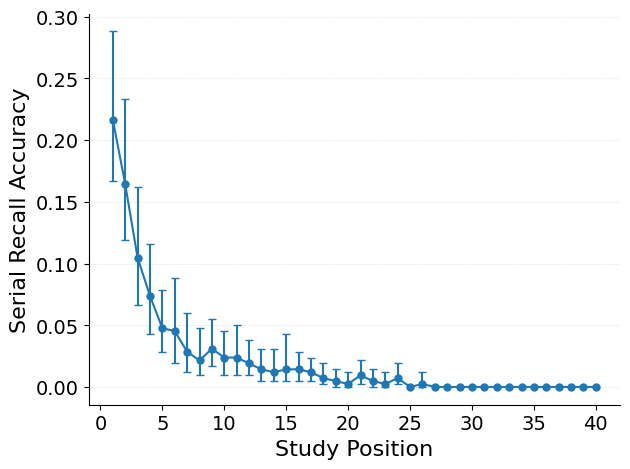

In [5]:
#| code-summary: Plot serial recall accuracy
#| label: fig-srac
#| fig-cap: "Serial recall accuracy curve showing position-specific accuracy."
plot_srac(datasets=data, trial_masks=trial_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_srac)

---

### plot_srac

>      plot_srac (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcmr.ty
>                 ping.RecallDataset], trial_masks:Union[Sequence[jaxtyping.Bool
>                 [Array,'trial_count']],jaxtyping.Bool[Array,'trial_count']],
>                 color_cycle:Optional[list[str]]=None,
>                 labels:Optional[Sequence[str]]=None,
>                 contrast_name:Optional[str]=None,
>                 axis:Optional[matplotlib.axes._axes.Axes]=None, size:int=3,
>                 confidence_level:float=0.95)

*Plot serial recall accuracy with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for each curve. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the SRAC plot.** |

In [7]:
#| echo: false
show_doc(srac)

---

### srac

>      srac (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Proportion of correct recalls at each study position.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'study_positions']** |  | **Mean accuracy at each study position.** |

In [8]:
# Position 1 correct in both trials; positions 2 and 3 correct in one
recalls = jnp.array([[1, 2, 0], [1, 0, 3]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3], [1, 2, 3]], dtype=jnp.int32)

dataset = {
    "subject": jnp.ones((2, 1), dtype=jnp.int32),
    "listLength": jnp.full((2, 1), 3, dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": recalls,
}

result = srac(dataset)
assert jnp.allclose(result, jnp.array([1.0, 0.5, 0.5]))

In [9]:
#| echo: false
show_doc(trial_srac)

---

### trial_srac

>      trial_srac (recalls:jaxtyping.Integer[Array,'recall_positions'],
>                  presentations:jaxtyping.Integer[Array,'study_positions'],
>                  size:int=3)

*Flag each study position as correctly recalled or not.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| recalls | Integer[Array, 'recall_positions'] |  | 1-indexed recalls for one trial; 0 for no recall. |
| presentations | Integer[Array, 'study_positions'] |  | Item IDs in study order. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Bool[Array, 'study_positions']** |  | **True where the study position was correctly recalled.** |

In [10]:
# All positions recalled correctly
result = trial_srac(
    jnp.array([1, 2, 3], dtype=jnp.int32),
    jnp.array([1, 2, 3], dtype=jnp.int32),
)
assert jnp.allclose(result, jnp.array([True, True, True]))